# Chapter 106 — Polar Coordinates

> **Prerequisites:** ch100 (Angles), ch093 (Cartesian)
>
> **Outcomes:** Convert between Cartesian and polar coordinates; Plot polar curves; Understand when polar coordinates simplify a problem


## Polar vs Cartesian

**Polar coordinates:** a point P = (r, θ) where r is distance from origin, θ is angle from positive x-axis.

**Conversion:**
- Polar → Cartesian: x = r·cos(θ), y = r·sin(θ)
- Cartesian → Polar: r = √(x²+y²), θ = atan2(y, x)

**When polar is simpler:**
- Circles: r = c (constant)
- Spirals: r = a·θ (Archimedean), r = e^(aθ) (logarithmic)
- Roses: r = a·cos(nθ) — symmetric petal curves
- Cardioids: r = a(1 + cos(θ))

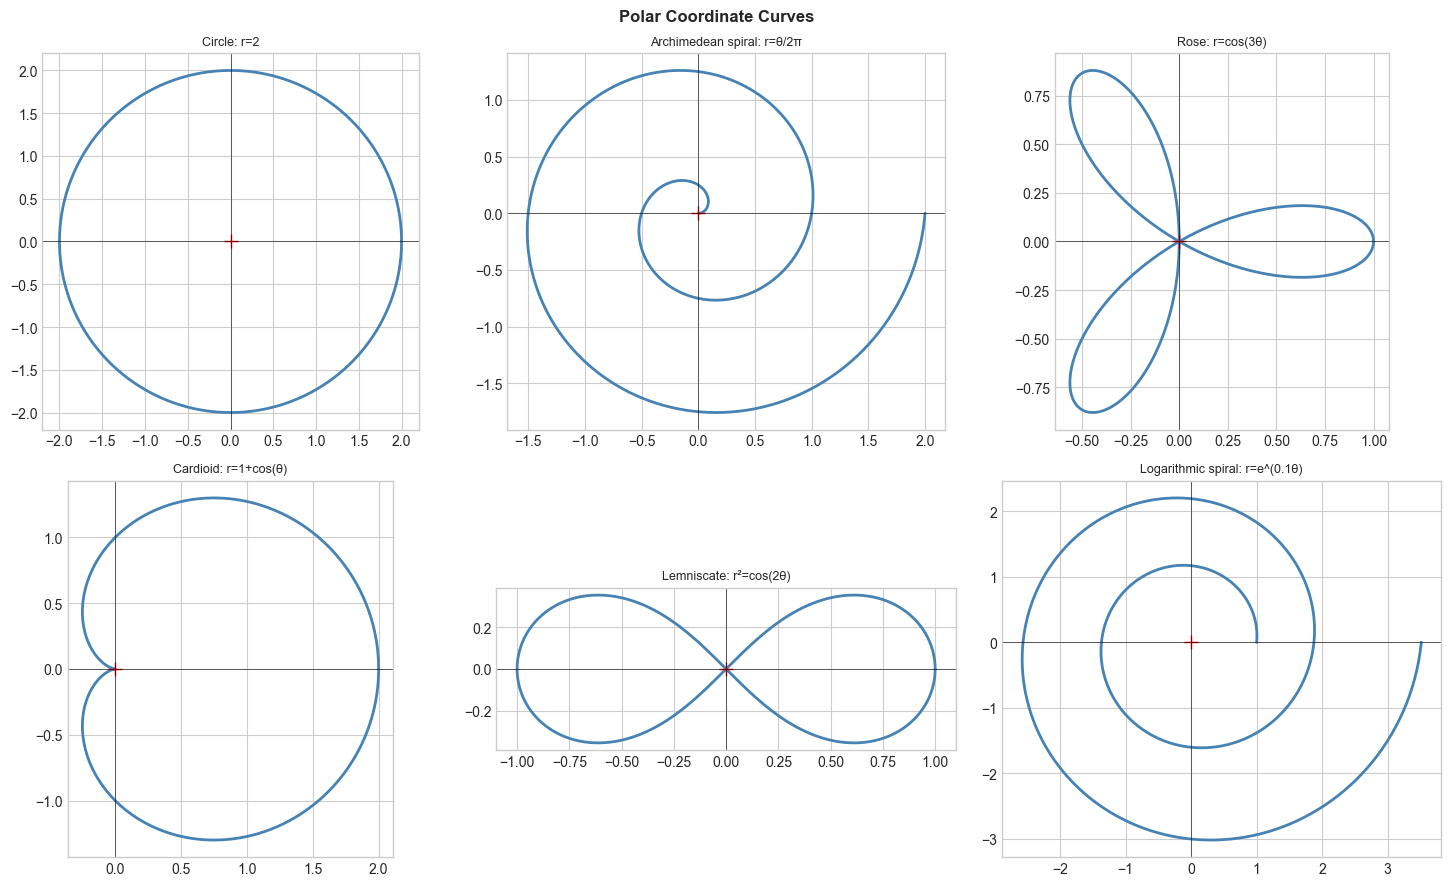

Cartesian (3, 4) → Polar: (np.float64(5.0), np.float64(0.9272952180016122))
Polar (5, π/4) → Cartesian: (np.float64(3.5355339059327378), np.float64(3.5355339059327378))


In [2]:
# --- Polar coordinate curves ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

theta = np.linspace(0, 4*np.pi, 2000)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

curves = [
    ('Circle: r=2', lambda t: np.full_like(t, 2.0), (0, 2*np.pi)),
    ('Archimedean spiral: r=θ/2π', lambda t: t/(2*np.pi), (0, 4*np.pi)),
    ('Rose: r=cos(3θ)', lambda t: np.cos(3*t), (0, np.pi)),
    ('Cardioid: r=1+cos(θ)', lambda t: 1+np.cos(t), (0, 2*np.pi)),
    ('Lemniscate: r²=cos(2θ)', lambda t: np.sqrt(np.maximum(0, np.cos(2*t))), (0, 2*np.pi)),
    ('Logarithmic spiral: r=e^(0.1θ)', lambda t: np.exp(0.1*t), (0, 4*np.pi)),
]

for ax, (name, r_fn, (t0, t1)) in zip(axes.flat, curves):
    t = np.linspace(t0, t1, 1000)
    r = r_fn(t)
    x = r * np.cos(t)
    y = r * np.sin(t)
    ax.plot(x, y, color='steelblue', lw=2)
    ax.plot(0, 0, 'r+', markersize=10)
    ax.set_aspect('equal'); ax.set_title(name, fontsize=9)
    ax.axhline(0, color='k', linewidth=0.4); ax.axvline(0, color='k', linewidth=0.4)

plt.suptitle('Polar Coordinate Curves', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Conversion demo
def cart_to_polar(x, y):
    return np.sqrt(x**2 + y**2), np.arctan2(y, x)

def polar_to_cart(r, theta):
    return r*np.cos(theta), r*np.sin(theta)

print("Cartesian (3, 4) → Polar:", cart_to_polar(3, 4))
print("Polar (5, π/4) → Cartesian:", polar_to_cart(5, np.pi/4))

## Exercises

**Easy 1.** Convert (0, 5) to polar. Convert (3, π/6) to Cartesian.
**Easy 2.** What curve does r = constant describe? What about θ = constant?
**Medium.** Plot the four-petal rose r = cos(2θ) and the three-petal rose r = cos(3θ). How many petals does r = cos(nθ) have?
**Hard.** Compute the area enclosed by r = 1 + cos(θ) (cardioid) using the polar area formula: A = ½∫r²dθ.

## Summary

- Polar: (r,θ) — distance and angle. Converts to (r·cos θ, r·sin θ)
- Circles, spirals, roses: much simpler in polar
- atan2(y,x) for correct quadrant; np.sqrt(x²+y²) for radius

**Forward:** ch107 (Parametric Curves) generalizes polar; ch116 (Bézier) builds curves without explicit equations.